# Algoritmos

## Gerando dados

In [1]:
# Edição de matrizes
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem
from sklearn.metrics import mean_squared_error, silhouette_score

# Persistência de modelos e dados
from joblib import dump, load

# Acessa variáveis de ambiente
import os
try:
    os.chdir("aulas_teoricas")
except FileNotFoundError:
    pass

In [3]:
def func_dados(valor) -> float:
    valor_final = 5 + valor*2
    return valor_final

In [4]:
np.random.seed(42)

n = 200
b = np.random.randint(1, 20, n)
b[:10]

array([ 7, 15, 11,  8,  7, 19, 11, 11,  4,  8])

In [5]:
a = np.apply_along_axis(func_dados, 0, b)
a[:10]

array([19, 35, 27, 21, 19, 43, 27, 27, 13, 21])

In [6]:
df = pd.DataFrame(
    data={
        'x': a,
        'y': b
    }
).round(0)
df.head()

,x,y
0,19,7
1,35,15
2,27,11
3,21,8
4,19,7


In [7]:
def func_dados_erro(valor: int) -> float:
    erro = np.random.normal(0, 2, 1)
    valor_final = valor + erro[0]
    return valor_final

In [8]:
df['x_noise'] = df['x'].apply(func=func_dados_erro)
df['y_noise'] = df['y'].apply(func=func_dados_erro)
df.head()

,x,y,x_noise,y_noise
0,19,7,21.338415,6.365262
1,35,15,36.746634,15.916883
2,27,11,27.411300,11.372425
3,21,8,18.113033,9.652381
4,19,7,16.944578,9.653008


In [9]:
def novo_valor(valor: int, correct: float, q1y: float, q3y: float) -> float:
    if valor <= q1y:
        return valor + correct
    if valor >= q3y:
        return valor + correct
    return valor

In [10]:
q1y = df.y_noise.quantile(.25)
q3y = df.y_noise.quantile(.75)

df['y_noise_new'] = df['y_noise'].apply(func=novo_valor, args=(5, q1y, q3y))
df.head()

,x,y,x_noise,y_noise,y_noise_new
0,19,7,21.338415,6.365262,6.365262
1,35,15,36.746634,15.916883,20.916883
2,27,11,27.411300,11.372425,11.372425
3,21,8,18.113033,9.652381,9.652381
4,19,7,16.944578,9.653008,9.653008


In [11]:
minx = df.x_noise.min()
q1x = df.x_noise.quantile(.25)
q3x = df.x_noise.quantile(.75)
maxx = df.x_noise.max()

miny = df.y_noise_new.min()
q1y = df.y_noise_new.quantile(.25)
q3y = df.y_noise_new.quantile(.75)
maxy = df.y_noise_new.max()

noise = pd.DataFrame({
    'x':[minx, q1x, q3x, maxx],
    'y':[miny, q1y, q3y, maxy],
})
noise

,x,y
0,3.931870,-0.956338
1,14.210412,6.956809
2,33.169559,15.293368
3,47.122190,26.683950


In [12]:
lista_valores = list()

[lista_valores.append(x) for x in np.random.randint(minx, q1x, 50)]
[lista_valores.append(x) for x in np.random.randint(q1x, q3x, 100)]
[lista_valores.append(x) for x in np.random.randint(q3x, maxx, 50)]

df["x_noise_mean"] = np.array(lista_valores)

lista_valores = list()

[lista_valores.append(y) for y in np.random.randint(miny, q1y, 50)]
[lista_valores.append(y) for y in np.random.randint(q1y, q3y, 100)]
[lista_valores.append(y) for y in np.random.randint(q3y, maxy, 50)]

df["y_noise_mean"] = np.array(lista_valores)

df.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean
0,19,7,21.338415,6.365262,6.365262,8,0
1,35,15,36.746634,15.916883,20.916883,7,0
2,27,11,27.411300,11.372425,11.372425,13,4
3,21,8,18.113033,9.652381,9.652381,6,2
4,19,7,16.944578,9.653008,9.653008,13,5


In [13]:
df_1 = df.sample(frac=.5)
df_2 = df.sample(frac=.5)

In [14]:
df_1['class'] = True
df_1.loc[df_1['x_noise'].sample(frac=.75).index, 'class'] = False
df_1['class'].value_counts()

False    75
True     25
Name: class, dtype: int64

In [15]:
df_1['style'] = "o"
df_1.loc[df_1[df_1['class']].index, 'style'] = '+'
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style
53,41,18,41.101260,19.359319,24.359319,23,8,False,o
93,9,2,9.876045,3.050423,8.050423,23,9,True,+
20,37,16,36.714018,14.920509,19.920509,11,0,False,o
177,15,5,13.314530,2.728269,7.728269,42,21,False,o
26,15,5,17.686336,1.206506,6.206506,9,5,False,o


In [16]:
df_1['style'].value_counts()

o    75
+    25
Name: style, dtype: int64

In [17]:
df_1['style_2'] = "o"
df_1.loc[df_1[df_1['y_noise_new'] > 17].index, 'style_2'] = '+'
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o


In [ ]:
# dump(df_1, './data/05_aula_df_1')
# dump(df_2, './data/05_aula_df_2')
# dump(df, './data/05_aula_df')

['./data/05_aula_df']

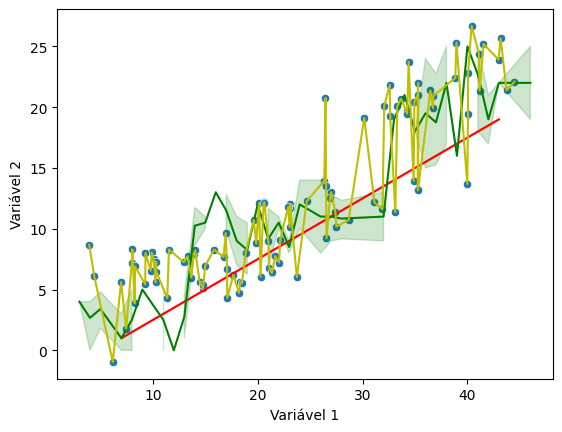

In [18]:
obsr = "Variável 1"
pred = "Variável 2"
sns.scatterplot(
    x='x_noise',
    y='y_noise_new',
    data=df_1
)
sns.lineplot(
    x='x',
    y='y',
    data=df_1,
    c='r',
)
sns.lineplot(
    x='x_noise_mean',
    y='y_noise_mean',
    data=df_1,
    c='g',
)
sns.lineplot(
    x='x_noise',
    y='y_noise_new',
    data=df_1,
    c='y',
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.show()

In [19]:
print(f"RMSE red: {mean_squared_error(df['x'], df['y'])}")
print(f"RMSE gree: {mean_squared_error(df['x_noise_mean'], df['y_noise_mean'])}")
print(f"RMSE yellow: {mean_squared_error(df['x_noise'], df['x_noise'])}")

RMSE red: 233.535
RMSE gree: 196.24
RMSE yellow: 0.0


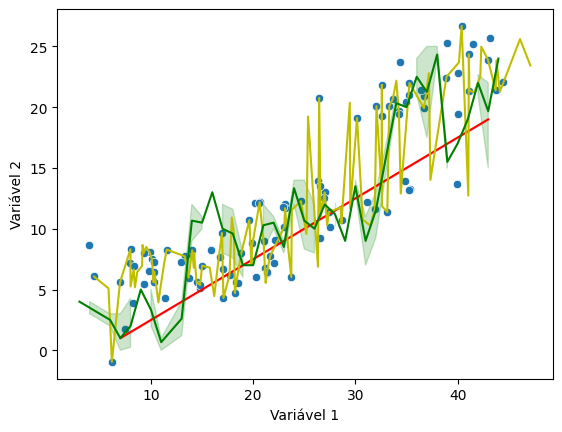

In [20]:
sns.scatterplot(
    x='x_noise',
    y='y_noise_new',
    data=df_1
)
sns.lineplot(
    x='x',
    y='y',
    data=df_2,
    c='r',
)
sns.lineplot(
    x='x_noise',
    y='y_noise_new',
    data=df_2,
    c='y',
)
sns.lineplot(
    x='x_noise_mean',
    y='y_noise_mean',
    data=df_2,
    c='g',
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.show()

In [21]:
print(f"RMSE red: {mean_squared_error(df_1['x'], df_2['y'])}")
print(f"RMSE gree: {mean_squared_error(df_1['x_noise_mean'], df_2['y_noise_mean'])}")
print(f"RMSE yellow: {mean_squared_error(df_1['x_noise'], df_2['x_noise'])}")

RMSE red: 397.8
RMSE gree: 323.6
RMSE yellow: 330.13960915380534
